# Project — E-commerce Sales & Customer Behaviour
## Phase 1: Exploratory Data Analysis (EDA)
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Tools:** Python, pandas, matplotlib, seaborn

## 1. Import Libraries

In [32]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Appl a global chart style - subtle horizontal lines behind bars/lines
# 'Muted' pallette gives softer colours
sns.set_theme(style='whitegrid', palette='muted')

# Set image resolution to 120 dpi
plt.rcParams['figure.dpi'] = 120

# String variable that stores the starting path of the data
DATA_PATH = '../data/raw/'

# Confirmation message when all libraries load successfully
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load All Datasets

In [33]:
# Read all 9 .csv files into 9 differnet pandas dataframes
orders        = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items   = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
order_payments= pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers     = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
products      = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers       = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
category_trans= pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')
geo           = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')

# Create a dictionary to store all dataframes
# For easy looping through all the dataframes
datasets = {
    'orders': orders, 
    'order_items': order_items,
    'order_payments': order_payments, 
    'order_reviews': order_reviews,
    'customers': customers, 
    'products': products,
    'sellers': sellers, 
    'category_translation': category_trans
}

# Printing dataset dimensions
print('Dataset shape summary:')
for name, df in datasets.items():
    print(f'  {name:<25} {df.shape[0]:>7,} rows  x  {df.shape[1]} cols')

Dataset shape summary:
  orders                     99,441 rows  x  8 cols
  order_items               112,650 rows  x  7 cols
  order_payments            103,886 rows  x  5 cols
  order_reviews              99,224 rows  x  7 cols
  customers                  99,441 rows  x  5 cols
  products                   32,951 rows  x  9 cols
  sellers                     3,095 rows  x  4 cols
  category_translation           71 rows  x  2 cols


## 3. Schema Overview — Understanding the Data Model

In [34]:
# Print column names and dtypes for the key tables
for name in ['orders', 'order_items', 'order_payments', 'customers']:
    print(f'\n--- {name.upper()} ---')
    print(datasets[name].dtypes.to_string())


--- ORDERS ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

--- ORDER_ITEMS ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

--- ORDER_PAYMENTS ---
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64

--- CUSTOMERS ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object


## 4. Data Quality Check — Nulls & Duplicates

In [35]:
# Check for null values
print('=== NULL VALUE COUNTS ===')
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print(f'\n{name}:')
        for col, count in nulls.items():
            pct = count / len(df) * 100
            print(f'  {col:<45} {count:>5,}  ({pct:.1f}%)')

# Check for duplicate values
print('\n=== DUPLICATE ROWS ===')
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f'  {name}: {duplicates:,} duplicate rows')
    else:
        print(f'  {name}: clean')

=== NULL VALUE COUNTS ===

orders:
  order_approved_at                               160  (0.2%)
  order_delivered_carrier_date                  1,783  (1.8%)
  order_delivered_customer_date                 2,965  (3.0%)

order_reviews:
  review_comment_title                          87,656  (88.3%)
  review_comment_message                        58,247  (58.7%)

products:
  product_category_name                           610  (1.9%)
  product_name_lenght                             610  (1.9%)
  product_description_lenght                      610  (1.9%)
  product_photos_qty                              610  (1.9%)
  product_weight_g                                  2  (0.0%)
  product_length_cm                                 2  (0.0%)
  product_height_cm                                 2  (0.0%)
  product_width_cm                                  2  (0.0%)

=== DUPLICATE ROWS ===
  orders: clean
  order_items: clean
  order_payments: clean
  order_reviews: clean
  customers: clean
 

## 5. Parse Datetime Columns

In [36]:
# List of column names that contain date/datetime data
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Convert all date data from object to datetime object
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Derived time features
orders['purchase_year']  = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_dow']   = orders['order_purchase_timestamp'].dt.day_name()
orders['purchase_hour']  = orders['order_purchase_timestamp'].dt.hour

# Delivery delay in days
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Check first 3 rows after parsing datetime columns
print('Datetime columns parsed. Sample:')
orders[['order_id', 'order_purchase_timestamp', 'purchase_year',
        'purchase_month', 'purchase_dow', 'delivery_delay_days']].head(3)

Datetime columns parsed. Sample:


,order_id,order_purchase_timestamp,purchase_year,purchase_month,purchase_dow,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017,10,Monday,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018,7,Tuesday,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018,8,Wednesday,-18.0


## 6. Order Status Distribution

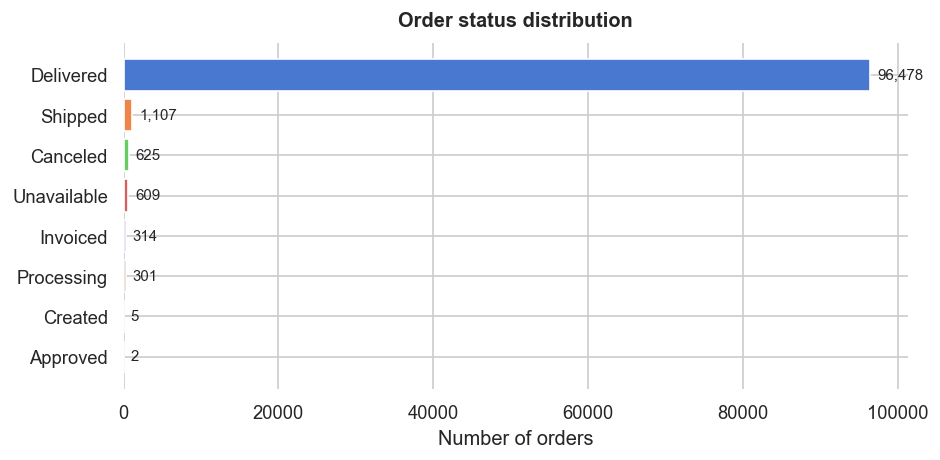


Delivered orders: 96,478 (97.0% of total)


In [37]:
# Check frequency of each order status
status_counts = orders['order_status'].value_counts()

# Define figure size
fig, ax = plt.subplots(figsize=(8, 4))
# Plot horizontal bar chart. 
# y axis - order status labels
# x axis - order status frequency
bars = ax.barh(status_counts.index.str.capitalize(), status_counts.values, color=sns.color_palette('muted', len(status_counts)))

# Add data labels for each bar. Define x and y axis labels
ax.bar_label(bars, labels= [f'{v:,.0f}' for v in bars.datavalues], padding=4, fontsize=9)
ax.set_xlabel('Number of orders')
ax.set_title('Order status distribution', fontweight='bold', pad=10)

# Flip y-axis to show most frequent status first
ax.invert_yaxis()
# Remove bottom and left axis lines 
sns.despine(left=True, bottom=True)

# Plot and save the graph in a png format
plt.tight_layout()
plt.savefig('../data/processed/plot_order_status.png', bbox_inches='tight')
plt.show()

# Focus on delivered orders only going forward
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'\nDelivered orders: {len(delivered):,} ({len(delivered)/len(orders)*100:.1f}% of total)')

## 7. Revenue Over Time

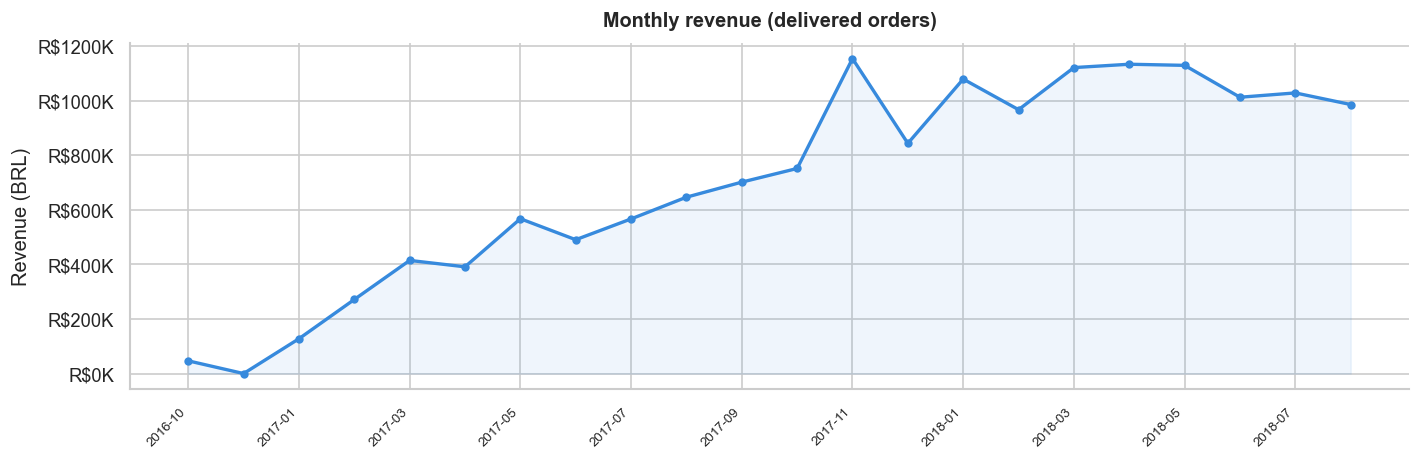

Total revenue (all time): R$15,422,462
Peak month: 2017-11  —  R$1,153,528


In [38]:
# Total payment per order
order_revenue = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'total_revenue']

# Merge with delivered orders
rev_time = delivered.merge(order_revenue, on='order_id')
rev_time['year_month'] = rev_time['order_purchase_timestamp'].dt.to_period('M')

monthly_rev = rev_time.groupby('year_month')['total_revenue'].sum().reset_index()
monthly_rev['year_month_str'] = monthly_rev['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_rev['year_month_str'], monthly_rev['total_revenue'],
        color='#378ADD', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_rev['year_month_str'], monthly_rev['total_revenue'],
                alpha=0.08, color='#378ADD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.set_xticks(monthly_rev['year_month_str'][::2])
ax.set_xticklabels(monthly_rev['year_month_str'][::2], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly revenue (delivered orders)', fontweight='bold', pad=10)
ax.set_ylabel('Revenue (BRL)')
sns.despine()
plt.tight_layout()
plt.savefig('../data/processed/plot_monthly_revenue.png', bbox_inches='tight')
plt.show()

total = monthly_rev['total_revenue'].sum()
peak  = monthly_rev.loc[monthly_rev['total_revenue'].idxmax()]
print(f'Total revenue (all time): R${total:,.0f}')
print(f'Peak month: {peak.year_month_str}  —  R${peak.total_revenue:,.0f}')

## 8. Order Volume — Day of Week & Hour of Day

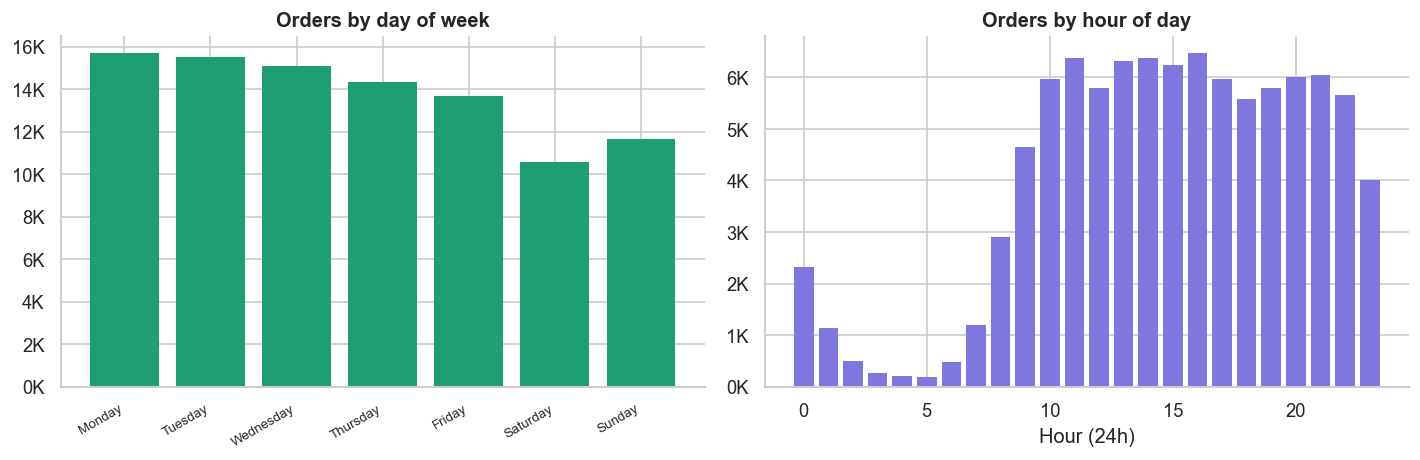

In [39]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = delivered['purchase_dow'].value_counts().reindex(dow_order)

hour_counts = delivered['purchase_hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(dow_counts.index, dow_counts.values, color='#1D9E75', edgecolor='none')
axes[0].set_title('Orders by day of week', fontweight='bold')
axes[0].set_xticklabels(dow_order, rotation=30, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].bar(hour_counts.index, hour_counts.values, color='#7F77DD', edgecolor='none')
axes[1].set_title('Orders by hour of day', fontweight='bold')
axes[1].set_xlabel('Hour (24h)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../data/processed/plot_order_timing.png', bbox_inches='tight')
plt.show()

## 9. Top Product Categories by Revenue

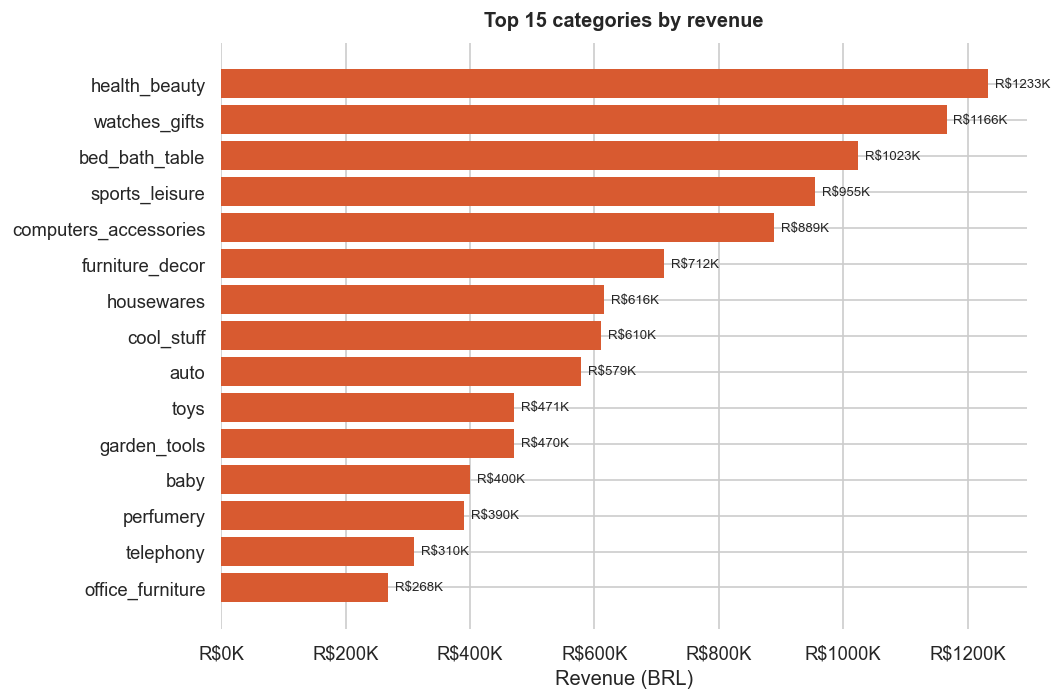

In [41]:
# Merge order items with products and category translation
items_prod = order_items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
items_prod = items_prod.merge(category_trans, on='product_category_name', how='left')
items_prod['category_en'] = items_prod['product_category_name_english'].fillna(
    items_prod['product_category_name'].fillna('unknown')
)

# Keep only delivered orders
items_delivered = items_prod[items_prod['order_id'].isin(delivered['order_id'])]

cat_rev = (
    items_delivered.groupby('category_en')['price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(cat_rev['category_en'][::-1], cat_rev['price'][::-1], color='#D85A30', edgecolor='none')
formatted_labels = [f'R${x/1000:.0f}K' for x in cat_rev['price'][::-1]]
ax.bar_label(bars, labels=formatted_labels, padding=4, fontsize=8)
ax.set_title('Top 15 categories by revenue', fontweight='bold', pad=10)
ax.set_xlabel('Revenue (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('../data/processed/plot_top_categories.png', bbox_inches='tight')
plt.show()

## 10. Payment Method Breakdown

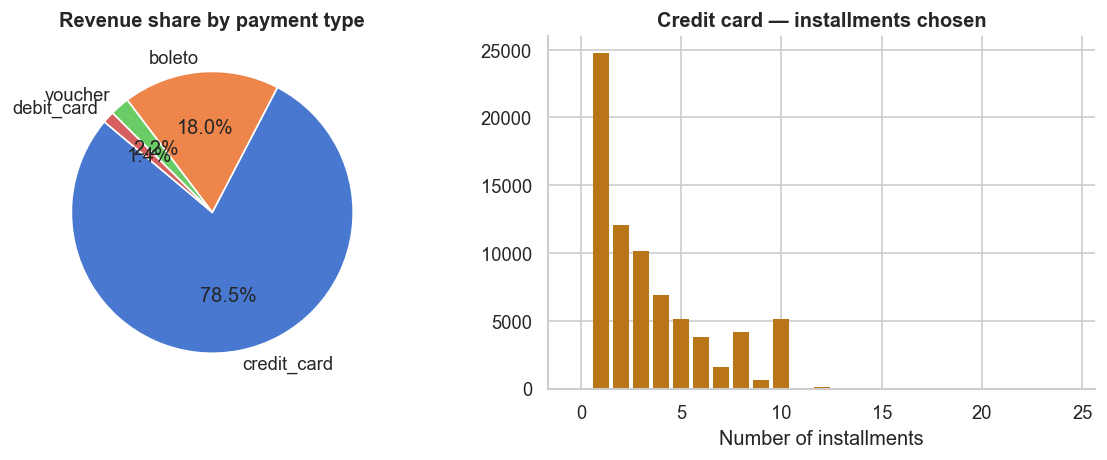

In [42]:
pay_delivered = order_payments[order_payments['order_id'].isin(delivered['order_id'])]
pay_type = pay_delivered.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart — share of revenue
axes[0].pie(pay_type.values, labels=pay_type.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(pay_type)))
axes[0].set_title('Revenue share by payment type', fontweight='bold')

# Installments distribution
installments = pay_delivered[pay_delivered['payment_type']=='credit_card']['payment_installments'].value_counts().sort_index()
axes[1].bar(installments.index, installments.values, color='#BA7517', edgecolor='none')
axes[1].set_title('Credit card — installments chosen', fontweight='bold')
axes[1].set_xlabel('Number of installments')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../data/processed/plot_payments.png', bbox_inches='tight')
plt.show()

## 11. Review Score Distribution & Average by Category

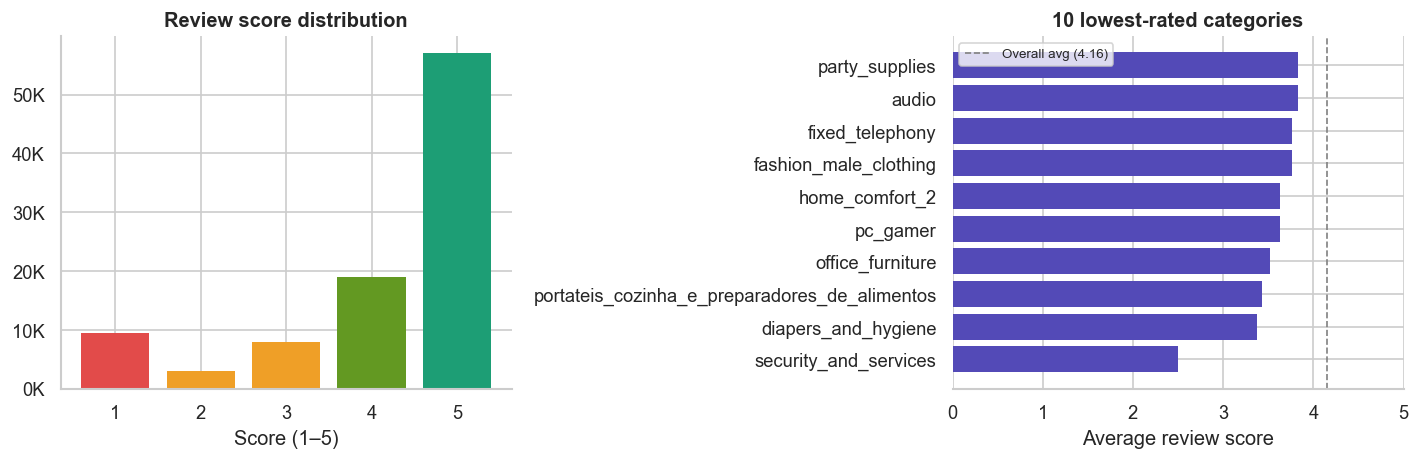

Overall avg review score: 4.16 / 5
5-star reviews: 59.2%


In [43]:
rev_delivered = order_reviews[order_reviews['order_id'].isin(delivered['order_id'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
score_dist = rev_delivered['review_score'].value_counts().sort_index()
colors = ['#E24B4A','#EF9F27','#EF9F27','#639922','#1D9E75']
axes[0].bar(score_dist.index, score_dist.values, color=colors, edgecolor='none')
axes[0].set_title('Review score distribution', fontweight='bold')
axes[0].set_xlabel('Score (1–5)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
sns.despine(ax=axes[0])

# Average score per top category
items_with_review = items_delivered.merge(rev_delivered[['order_id','review_score']], on='order_id')
cat_score = (
    items_with_review.groupby('category_en')['review_score']
    .mean()
    .sort_values()
    .head(10)
)
axes[1].barh(cat_score.index, cat_score.values, color='#534AB7', edgecolor='none')
axes[1].set_xlim(0, 5)
axes[1].axvline(x=rev_delivered['review_score'].mean(), color='gray', linestyle='--', linewidth=1, label=f'Overall avg ({rev_delivered["review_score"].mean():.2f})')
axes[1].set_title('10 lowest-rated categories', fontweight='bold')
axes[1].set_xlabel('Average review score')
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.savefig('../data/processed/plot_reviews.png', bbox_inches='tight')
plt.show()

avg_score = rev_delivered['review_score'].mean()
pct_5star = (score_dist[5] / score_dist.sum() * 100)
print(f'Overall avg review score: {avg_score:.2f} / 5')
print(f'5-star reviews: {pct_5star:.1f}%')

## 12. Delivery Delay Analysis

On time or early: 89,936 (93.2%)
Late deliveries:  6,534 (6.8%)
Avg delay (late only): 10.6 days


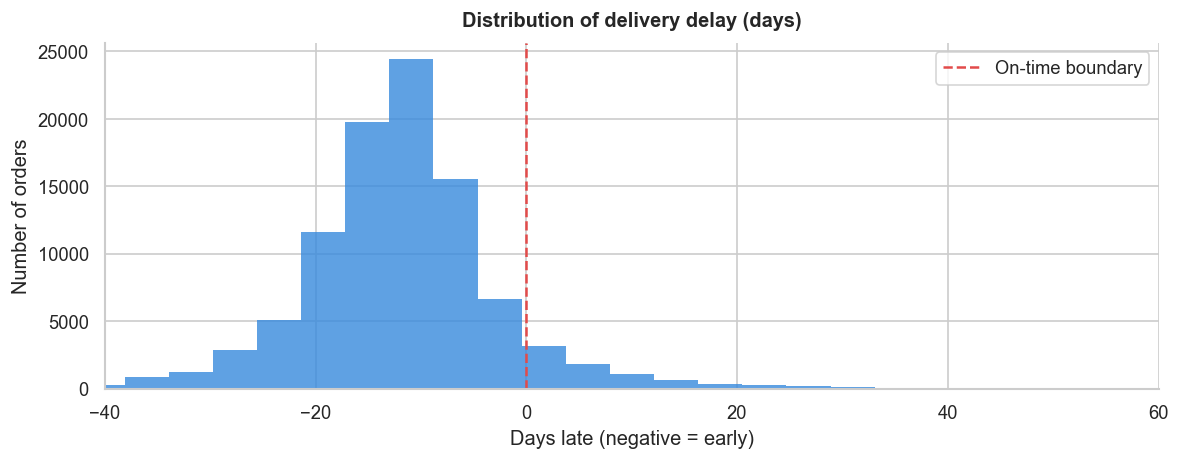

In [44]:
delay_df = delivered.dropna(subset=['delivery_delay_days']).copy()
late = delay_df[delay_df['delivery_delay_days'] > 0]
on_time = delay_df[delay_df['delivery_delay_days'] <= 0]

print(f'On time or early: {len(on_time):,} ({len(on_time)/len(delay_df)*100:.1f}%)')
print(f'Late deliveries:  {len(late):,} ({len(late)/len(delay_df)*100:.1f}%)')
print(f'Avg delay (late only): {late["delivery_delay_days"].mean():.1f} days')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delay_df['delivery_delay_days'], bins=80, color='#378ADD',
        edgecolor='none', alpha=0.8)
ax.axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--', label='On-time boundary')
ax.set_xlim(-40, 60)
ax.set_title('Distribution of delivery delay (days)', fontweight='bold', pad=10)
ax.set_xlabel('Days late (negative = early)')
ax.set_ylabel('Number of orders')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../data/processed/plot_delivery_delay.png', bbox_inches='tight')
plt.show()

## 13. Customer Geography — Orders by State

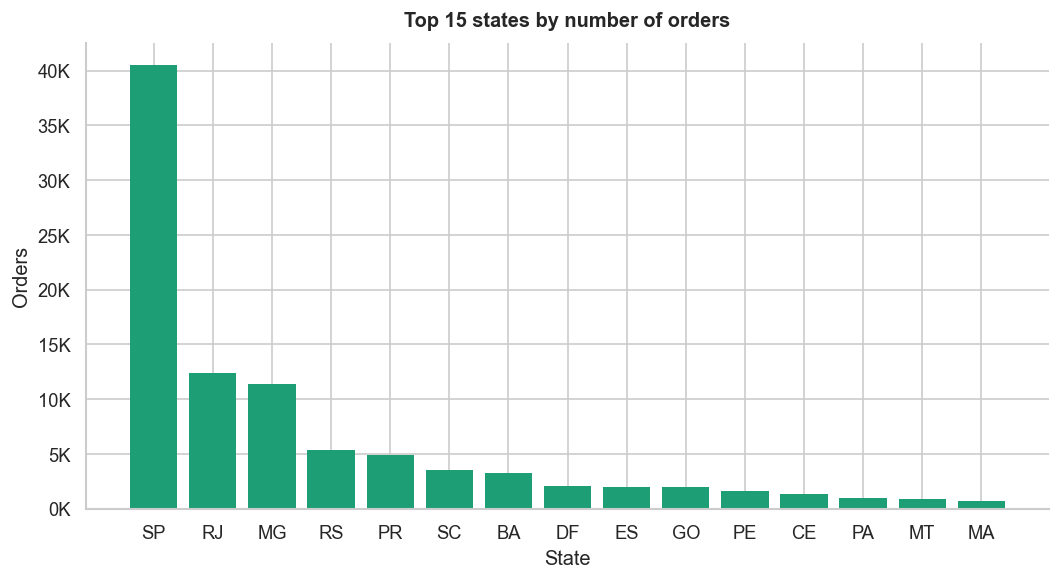

In [45]:
cust_state = customers[['customer_id','customer_state']]
orders_state = delivered.merge(cust_state, on='customer_id')
state_counts = orders_state['customer_state'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(state_counts.index, state_counts.values, color='#1D9E75', edgecolor='none')
ax.set_title('Top 15 states by number of orders', fontweight='bold', pad=10)
ax.set_xlabel('State')
ax.set_ylabel('Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
sns.despine()
plt.tight_layout()
plt.savefig('../data/processed/plot_orders_by_state.png', bbox_inches='tight')
plt.show()

## 14. Save Cleaned Master Table for Phase 2 (SQL)

In [46]:
# Build a master analytical table joining all key dimensions
master = (
    delivered
    .merge(order_revenue, on='order_id', how='left')
    .merge(customers[['customer_id','customer_state','customer_city']], on='customer_id', how='left')
    .merge(
        items_delivered.groupby('order_id').agg(
            num_items=('order_item_id','count'),
            items_revenue=('price','sum'),
            freight_value=('freight_value','sum'),
            category_en=('category_en', lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
        ).reset_index(),
        on='order_id', how='left'
    )
    .merge(
        rev_delivered.groupby('order_id')['review_score'].mean().reset_index(),
        on='order_id', how='left'
    )
    .merge(
        pay_delivered.groupby('order_id')['payment_type'].agg(lambda x: x.mode()[0]).reset_index(),
        on='order_id', how='left'
    )
)

os.makedirs('../data/processed', exist_ok=True)
master.to_csv('../data/processed/master_orders.csv', index=False)

print(f'Master table saved: {master.shape[0]:,} rows x {master.shape[1]} columns')
print('\nColumns:', list(master.columns))
master.head(3)

Master table saved: 96,478 rows x 22 columns

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'purchase_year', 'purchase_month', 'purchase_dow', 'purchase_hour', 'delivery_delay_days', 'total_revenue', 'customer_state', 'customer_city', 'num_items', 'items_revenue', 'freight_value', 'category_en', 'review_score', 'payment_type']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,delivery_delay_days,total_revenue,customer_state,customer_city,num_items,items_revenue,freight_value,category_en,review_score,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,-8.0,38.71,SP,sao paulo,1,29.99,8.72,housewares,4.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,-6.0,141.46,BA,barreiras,1,118.70,22.76,perfumery,4.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,-18.0,179.12,GO,vianopolis,1,159.90,19.22,auto,5.0,credit_card


## 15. EDA Summary

| Metric | Value |
|--------|-------|
| Total delivered orders | ~96,000 |
| Date range | Sep 2016 – Sep 2018 |
| Top category by revenue | Bed, bath & table |
| Most common payment | Credit card (~74%) |
| Avg review score | ~4.07 / 5 |
| Late delivery rate | ~8% |
| Top state | SP (São Paulo) |